# Daily environment report — map + issue and island bars

Where environmental issues are being reported across Indonesia, which issues they are,
and how they distribute across the islands. One choropleth plus two horizontal bar
charts, built with `great.viz.environment`.

## One-time setup

The map needs the `[geo]` extra (geopandas, shapely, requests) on top of the usual install:

```
py -3.11 -m pip install -e "C:\Users\ASUS\Documents\Research Project\GREAT Big Data Analysis Program[all]"
```

`[all]` covers it. If you installed with just `[viz]` earlier, re-run the line above — `great.viz.environment`
imports geopandas at module level and will not import without it.

On first use the module downloads the 38-province GeoJSON once and caches it in your user
directory, so that step only costs you network time the first time.

In [1]:
# Pick up edits to the great/ source without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from great import classify_issue, resolve_frame, validate_export
from great.viz import prep
from great.viz.environment import env_two_bar

## 1. Load and validate

The environmental export uses the same 13-column schema as every other export in this
portfolio, so `validate_export()` applies unchanged — it fails at load time if a column is
missing or a Sentiment/Media value falls outside the canonical vocabulary.

In [3]:
DATA = r'C:\Users\ASUS\Documents\Research Project\Data\Iklim dan Lingkungan'

df = pd.read_excel(rf'{DATA}\test_data.xlsx', header=1)
df = validate_export(df)

df1, start_date, end_date = prep.prepare_data(df)
print(f'{len(df1):,} rows | {start_date} - {end_date}')

1,465 rows | 11 Sep 2026 - 11 Sep 2026


## 2. Derive `Isu_Inti` and `Provinsi`

Neither column exists in a raw export — both reports need them, and this is where the rest of
the library does the work.

**The issue category** comes from `classify_issue()`, the keyword rules in `great/issues.py`.

**The province** comes from `resolve_frame()`, which scans the headline and
mention text against the 1,243-entry gazetteer in `great/geo.py` and falls back to the
structured `Location` column only for rows the text cannot place.

Text wins deliberately. In this export `Location` is the *author’s* location — measured over
25k rows the two disagree 74% of the time, with `Location="Jakarta"` on articles about fires
in Kalimantan. For a map of where issues are *happening*, the article text is the right
signal.

It returns `Pulau` as well, which the island bar chart uses.

In [4]:
df1['Isu_Inti'] = df1['Mentions'].map(classify_issue)
df1[['Provinsi', 'Pulau']] = resolve_frame(df1)

counts = df1['Provinsi'].value_counts()
unresolved = counts.get('Tidak Terdeteksi', 0) + counts.get('Provinsi Tidak Spesifik', 0)
print(f'resolved to a province: {len(df1) - unresolved:,} of {len(df1):,} '
      f'({(len(df1) - unresolved) / len(df1):.1%})')
counts.head(10)

resolved to a province: 984 of 1,465 (67.2%)


Provinsi
Tidak Terdeteksi           435
Kalimantan Tengah          157
Kalimantan Selatan         142
Kalimantan Barat           101
Jawa Timur                  87
Kalimantan Timur            61
Riau                        49
Provinsi Tidak Spesifik     46
Sumatera Barat              46
Jawa Barat                  43
Name: count, dtype: int64

In [5]:
df1['Isu_Inti'].value_counts()

Isu_Inti
Kebakaran lingkungan         743
Perubahan iklim/emisi        344
Satwa/ekosistem              114
Sampah                       100
Polusi udara                  50
Tambang ilegal/ekstraktif     40
Kekeringan/Krisis Air         17
Deforestasi                   14
Pencemaran air/limbah         12
Banjir/longsor                11
Isu lingkungan lain            9
Konservasi/reboisasi           6
Bencana vulkanik               3
Abrasi/erosi                   2
Name: count, dtype: int64

## 3. The daily figure

`env_two_bar()` puts the map down the left at full height and stacks two bar
charts on the right: issue categories on top, cases per island underneath. Compared with the
weekly report the map also carries a colorbar, and the badges scale with the count so the
busiest provinces read at a glance.

The island chart maps provinces through `great.geo.PULAU_MAP`. It is sorted by count by
default; pass `island_order='geographic'` to order it west-to-east instead, matching
`great.geo.ISLAND_ORDER` so the bars read in the same order as the map.

Because the badges scale here, `badge_size` is the size of the *smallest* one rather than a
fixed size: with `badge_size=12` and `badge_growth=5` the quietest province reads at 12pt and
the busiest at 17pt. Set `badge_growth=0` for uniform badges.

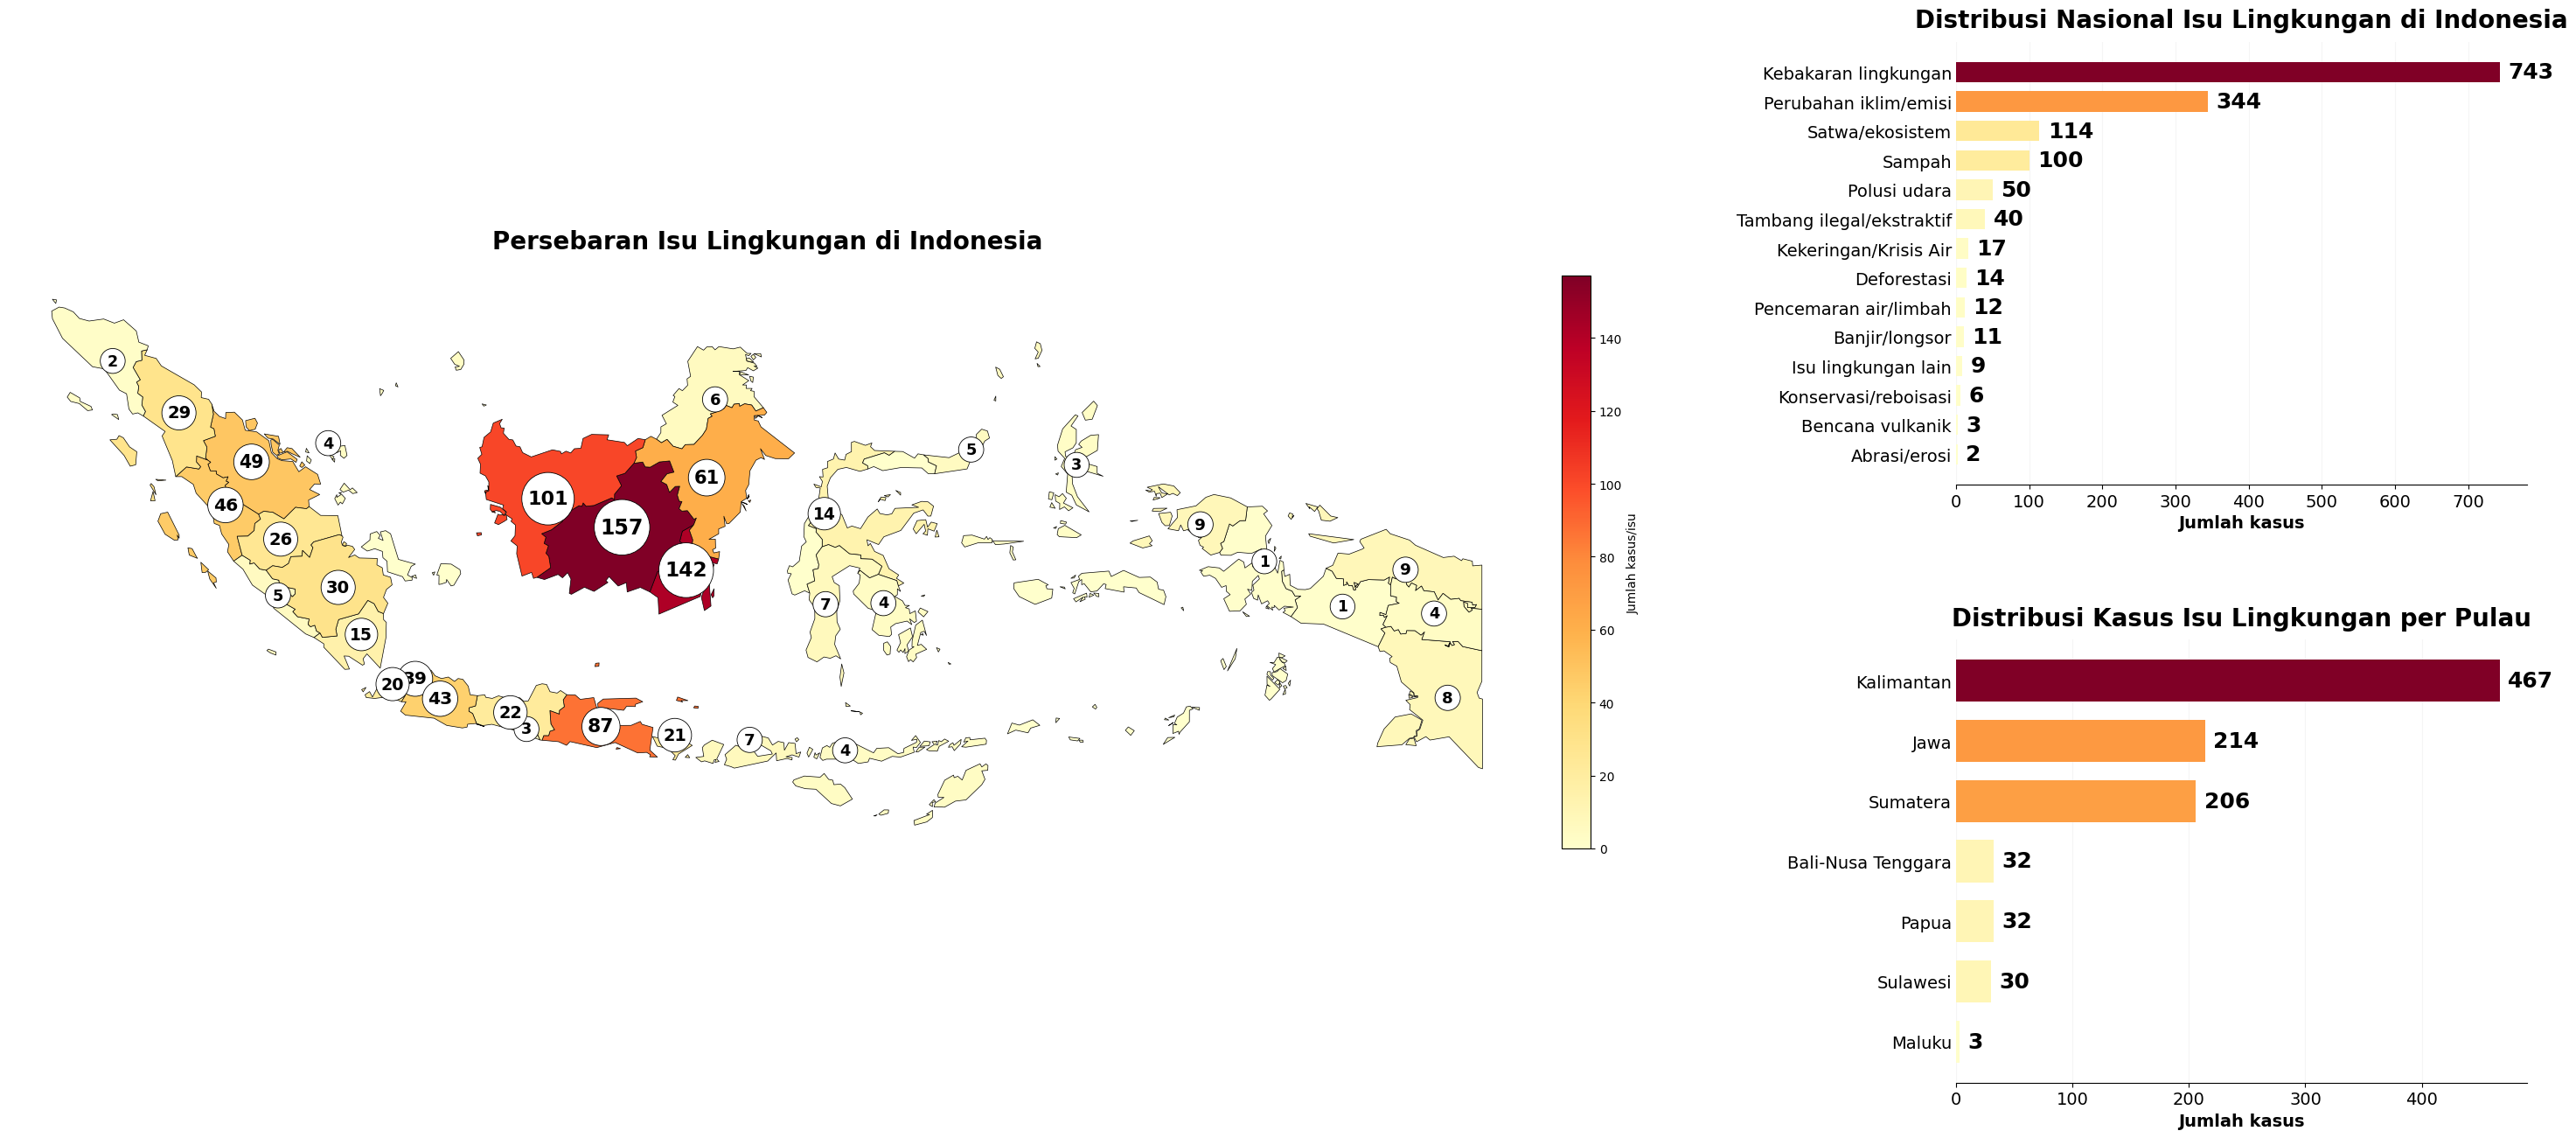

In [6]:
fig = env_two_bar(
    df1,
    start_date=start_date,
    end_date=end_date,
    island_order='count',   # or 'geographic'
    badge_size=12,          # smallest badge; the busiest province gets 12 + badge_growth
    badge_growth=5,         # set to 0 for uniform badges, like the weekly report
)

## 4. The numbers behind the figure

The same aggregations the report uses, available separately when you want the table rather
than the picture.

In [7]:
import pandas as pd

from great import classify_issue, resolve_frame, validate_export
from great.viz import prep
from great.viz.environment import env_two_bar

---

## Where things live

| Import | Contents |
|---|---|
| `great` | `classify_issue`, `resolve`, `resolve_frame`, `validate_export`, label and palette constants |
| `great.geo` | The 572-entry gazetteer, `PROVINCE_FIX`, `GEO_FIX`, `PULAU_MAP`, `ISLAND_ORDER` |
| `great.viz.prep` | `prepare_data()` and the other reshaping helpers |
| `great.viz.environment` | `env_one_bar()`, `env_two_bar()`, `province_counts()`, `island_counts()`, `load_indonesia_geojson()` |

The companion notebook in this folder covers the other report. See `TUTORIAL.md` for the full
library guide and `CONTRIBUTING.md` for how to change it.